# B_S2.3 — Null vs Signal Distribution Range Analysis

For each metric, compare the **distribution range** across 4 relationship categories:

| Mean response | Variance | Category | Model |
|:---:|:---:|:---|:---|
| Constant | Constant (indep. of X) | **true_null** | Y = c + σ₀ε |
| Changes with X | Constant (indep. of X) | **mean_only** | Y = f(X) + σ₀ε |
| Constant | Changes with X | **variance_only** | Y = c + σ(X)ε |
| Changes with X | Changes with X | **mean+variance** | Y = f(X) + σ(X)ε |

Key questions:
1. How wide is each signal category's range compared to the null range? (range ratio)
2. How much do signal and null distributions overlap? (overlap fraction)
3. Which metrics best separate each signal category from null?
4. Which metrics are consistent across all x_distribution types?

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

VIZ_DIR = Path('output/S2.3')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

In [24]:
S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

metrics_df = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_all = pd.concat([cases_main, cases_null], ignore_index=True)

label_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category', 'source']
df = metrics_df.merge(cases_all[label_cols], on=['case_id', 'source'], how='left')

non_metric = {'case_id', 'source', 'n_valid', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category'}
metric_cols = sorted([c for c in df.columns if c not in non_metric])

x_dists = sorted(df['x_distribution'].dropna().unique())
categories = ['true_null', 'mean_only', 'variance_only', 'mean+variance']
signal_cats = ['mean_only', 'variance_only', 'mean+variance']

print(f'Total cases: {len(df):,}')
print(f'Metric columns: {len(metric_cols)}')
print(f'x_distribution groups ({len(x_dists)}): {x_dists}')
print()
print(df['category'].value_counts())

Total cases: 121,056
Metric columns: 75
x_distribution groups (8): ['center_dense', 'clusters_2', 'clusters_3', 'clusters_4', 'clusters_5', 'even', 'left_dense', 'right_dense']

category
mean+variance    85536
mean_only        28512
true_null         4032
variance_only     2976
Name: count, dtype: int64


## Compute Range Statistics per (metric, x_distribution, category)

For each combination, compute:
- 95% range: [p2.5, p97.5]
- Range length = p97.5 - p2.5
- Median

In [25]:
range_rows = []
for m in metric_cols:
    for xd in x_dists:
        for cat in categories:
            vals = df.loc[(df['x_distribution'] == xd) & (df['category'] == cat), m].dropna().values
            if len(vals) < 5:
                continue
            p2_5, p25, p50, p75, p97_5 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])
            range_rows.append({
                'metric': m,
                'x_distribution': xd,
                'category': cat,
                'p2_5': p2_5,
                'p25': p25,
                'median': p50,
                'p75': p75,
                'p97_5': p97_5,
                'range_95': p97_5 - p2_5,
                'iqr': p75 - p25,
                'n': len(vals),
            })

range_df = pd.DataFrame(range_rows)
print(f'Computed {len(range_df):,} range statistics')
print(f'  ({len(metric_cols)} metrics × {len(x_dists)} x_dists × {len(categories)} categories)')

Computed 2,400 range statistics
  (75 metrics × 8 x_dists × 4 categories)


## Compute Comparison Metrics: Signal vs Null

For each (metric, x_distribution, signal_category) vs true_null:
- **Range ratio**: signal_range_95 / null_range_95 — how much wider is signal?
- **Overlap fraction**: how much of the signal 95% range overlaps with the null 95% range?
- **Non-overlap fraction**: 1 - overlap_fraction — the useful part
- **Median shift**: |signal_median - null_median| / null_range_95 — how far the center moved

In [26]:
null_range = range_df[range_df['category'] == 'true_null'].set_index(['metric', 'x_distribution'])

comp_rows = []
for cat in signal_cats:
    sig = range_df[range_df['category'] == cat].set_index(['metric', 'x_distribution'])
    for (m, xd) in sig.index:
        if (m, xd) not in null_range.index:
            continue
        nr = null_range.loc[(m, xd)]
        sr = sig.loc[(m, xd)]

        null_lo, null_hi = nr['p2_5'], nr['p97_5']
        sig_lo, sig_hi = sr['p2_5'], sr['p97_5']
        null_len = nr['range_95']
        sig_len = sr['range_95']

        # Range ratio
        range_ratio = sig_len / null_len if null_len > 1e-12 else np.nan

        # Overlap length
        overlap_lo = max(null_lo, sig_lo)
        overlap_hi = min(null_hi, sig_hi)
        overlap_len = max(0, overlap_hi - overlap_lo)

        # Overlap as fraction of signal range
        overlap_frac_of_signal = overlap_len / sig_len if sig_len > 1e-12 else np.nan
        # Overlap as fraction of null range
        overlap_frac_of_null = overlap_len / null_len if null_len > 1e-12 else np.nan

        # Non-overlap: fraction of signal range that is outside null range
        non_overlap_frac = 1 - overlap_frac_of_signal if overlap_frac_of_signal is not np.nan else np.nan

        # Median shift normalized by null range
        median_shift = abs(sr['median'] - nr['median']) / null_len if null_len > 1e-12 else np.nan

        comp_rows.append({
            'metric': m,
            'x_distribution': xd,
            'category': cat,
            'null_range_95': null_len,
            'signal_range_95': sig_len,
            'range_ratio': range_ratio,
            'overlap_len': overlap_len,
            'overlap_frac_of_signal': overlap_frac_of_signal,
            'overlap_frac_of_null': overlap_frac_of_null,
            'non_overlap_frac': non_overlap_frac,
            'median_shift': median_shift,
        })

comp_df = pd.DataFrame(comp_rows)
print(f'Computed {len(comp_df):,} signal-vs-null comparisons')
print()

# Aggregate: mean across x_distribution groups (per metric × category)
agg = comp_df.groupby(['metric', 'category']).agg(
    mean_range_ratio=('range_ratio', 'mean'),
    mean_non_overlap=('non_overlap_frac', 'mean'),
    mean_median_shift=('median_shift', 'mean'),
    std_range_ratio=('range_ratio', 'std'),
).reset_index()

# Overall score: average non_overlap across all 3 signal categories
overall = agg.groupby('metric').agg(
    mean_non_overlap=('mean_non_overlap', 'mean'),
    mean_range_ratio=('mean_range_ratio', 'mean'),
    mean_median_shift=('mean_median_shift', 'mean'),
).sort_values('mean_non_overlap', ascending=False)

print('Top 15 metrics by mean non-overlap fraction (higher = better separation):')
print(overall.head(15).to_string(float_format='{:.3f}'.format))

Computed 1,800 signal-vs-null comparisons

Top 15 metrics by mean non-overlap fraction (higher = better separation):
                                                        mean_non_overlap  mean_range_ratio  mean_median_shift
metric                                                                                                       
MCN                                                                1.000               NaN                NaN
distance_correlation                                               0.991             9.426              6.793
distance_covariance                                                0.979            31.963              4.218
MIC                                                                0.963            13.198              6.837
MEV                                                                0.944            13.310              6.755
MIC_minus_r2                                                       0.935            13.110              1.201
equ

## Fig 1: Distribution Ranges by Category — All 75 Metrics

All metrics sorted by mean non-overlap fraction (best at top).
Each subplot: 4 box plots (null / mean_only / variance_only / mean+variance).
Whiskers = 2.5–97.5 percentile range.

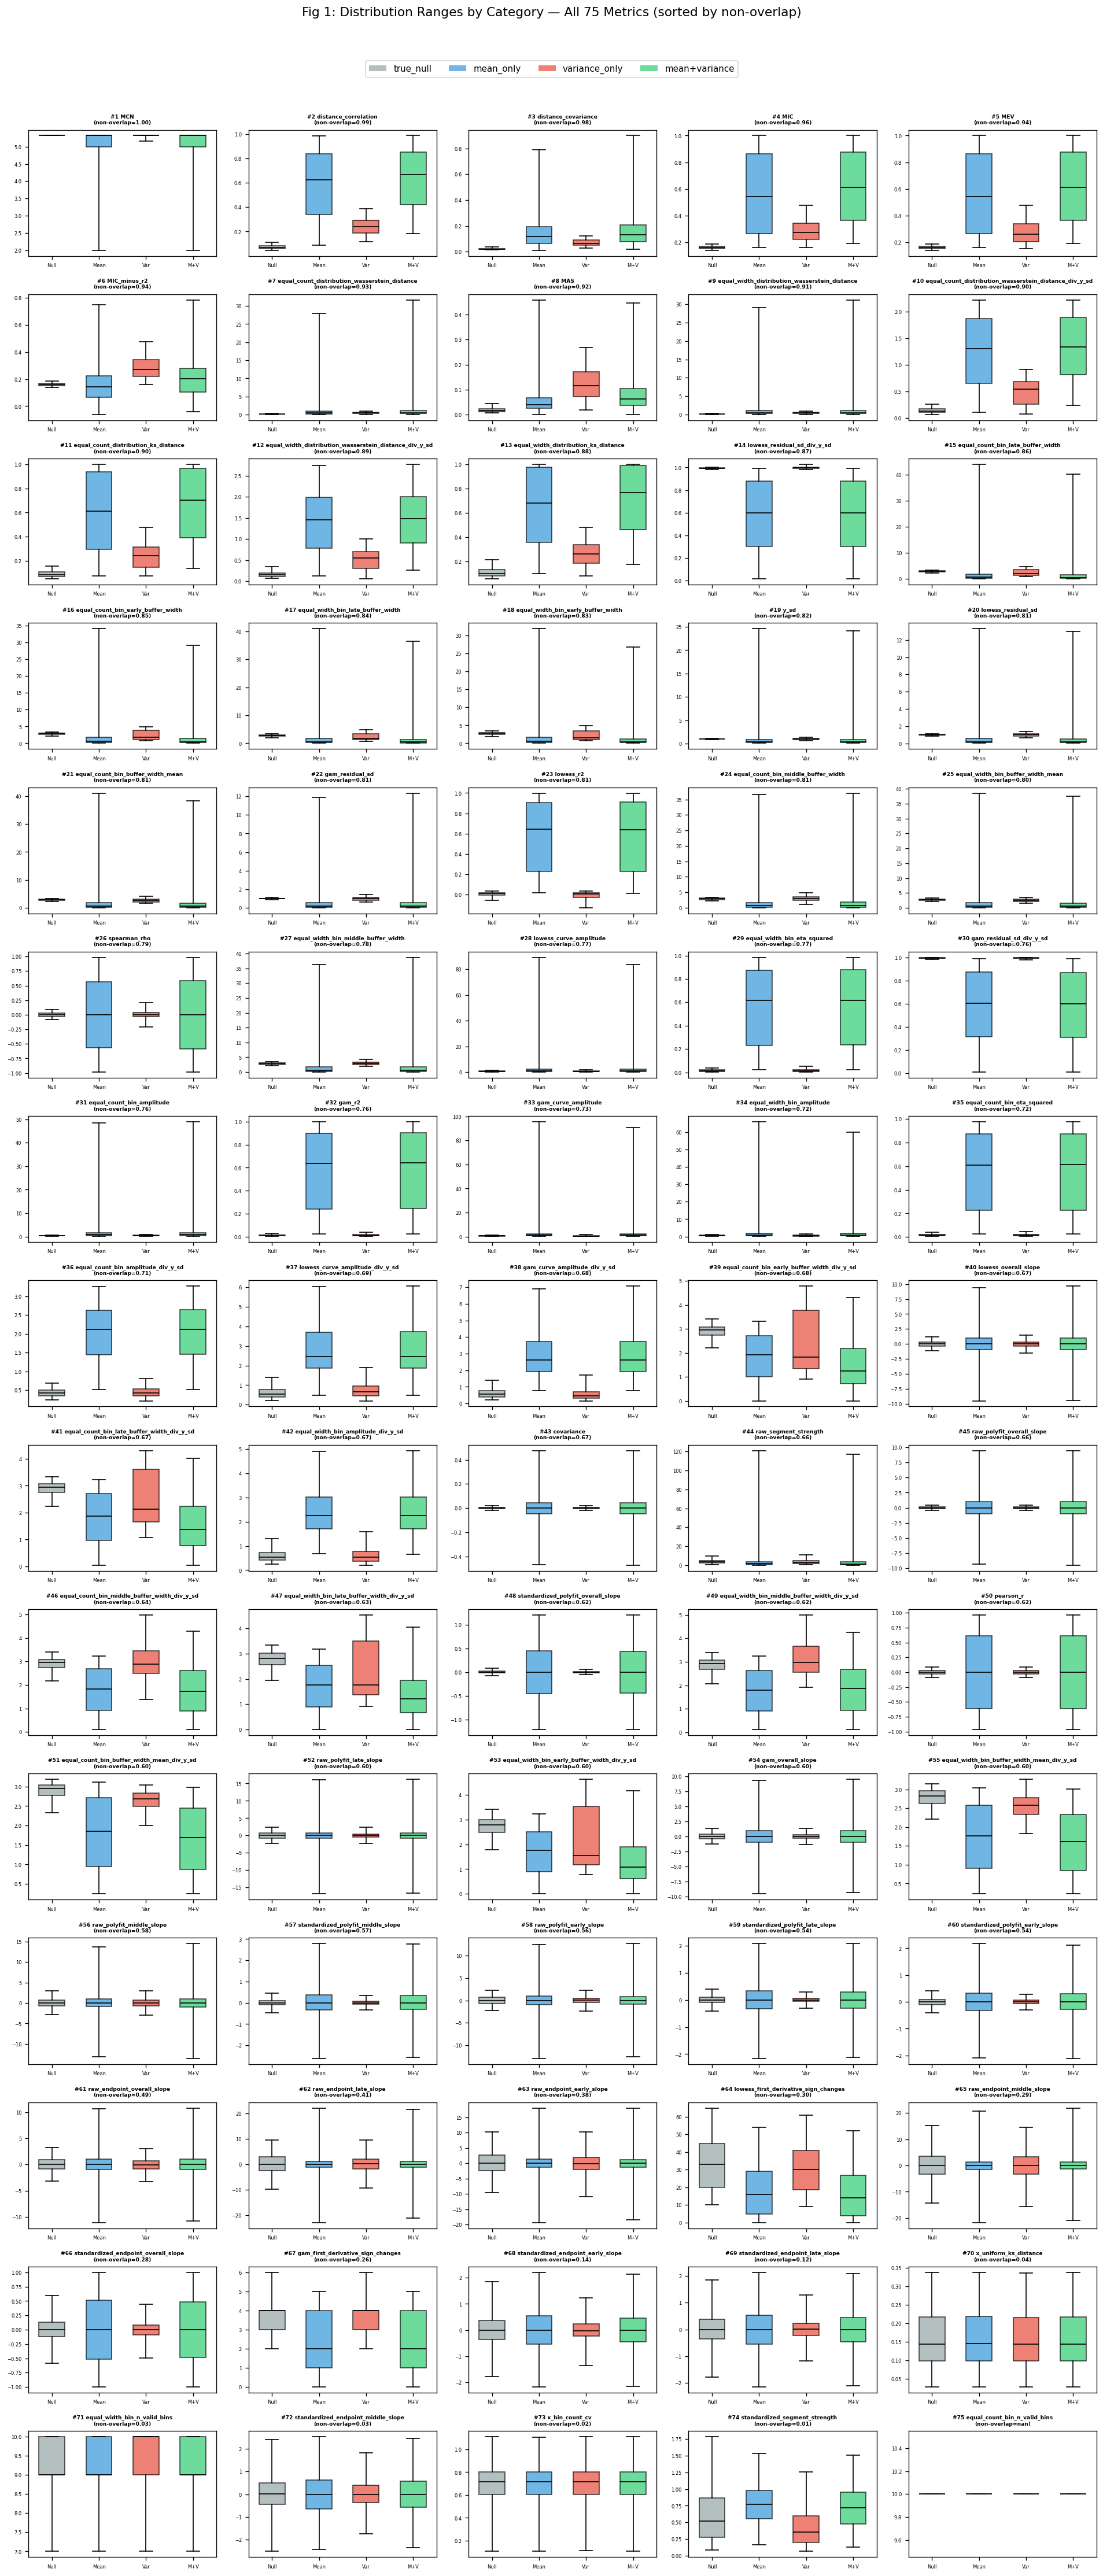

Saved → output/S2.3/fig1_range_by_category_all.png


In [27]:
from matplotlib.patches import Patch

cat_colors = {
    'true_null': '#95a5a6', 'mean_only': '#3498db',
    'variance_only': '#e74c3c', 'mean+variance': '#2ecc71',
}
cat_short = {
    'true_null': 'Null', 'mean_only': 'Mean',
    'variance_only': 'Var', 'mean+variance': 'M+V',
}

sorted_metrics = overall.index.tolist()
n_metrics = len(sorted_metrics)
n_cols = 5
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.4))
axes_flat = axes.flat

for idx, m in enumerate(sorted_metrics):
    ax = axes_flat[idx]
    box_data = []
    positions = []
    colors = []
    for j, cat in enumerate(categories):
        vals = df.loc[df['category'] == cat, m].dropna().values
        if len(vals) < 5:
            continue
        box_data.append(vals)
        positions.append(j)
        colors.append(cat_colors[cat])

    if box_data:
        bp = ax.boxplot(box_data, positions=positions, widths=0.55, patch_artist=True,
                        showfliers=False, medianprops={'color': 'black', 'linewidth': 1},
                        whis=[2.5, 97.5])
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels([cat_short[c] for c in categories], fontsize=5)
    score = overall.loc[m, 'mean_non_overlap']
    ax.set_title(f'#{idx+1} {m}\n(non-overlap={score:.2f})', fontsize=5.5, fontweight='bold')
    ax.tick_params(axis='y', labelsize=5)

for idx in range(n_metrics, n_rows * n_cols):
    axes_flat[idx].set_visible(False)

legend_elements = [Patch(facecolor=cat_colors[c], alpha=0.7, label=c) for c in categories]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle('Fig 1: Distribution Ranges by Category — All 75 Metrics (sorted by non-overlap)',
             fontsize=13, y=1.03)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig1_range_by_category_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig1_range_by_category_all.png"}')

## Fig 2: Non-Overlap Fraction Heatmap (metric × category)

For the top 30 metrics, show non-overlap fraction per signal category
(averaged across all x_distribution groups). This reveals which metrics
separate which types of relationships from null.

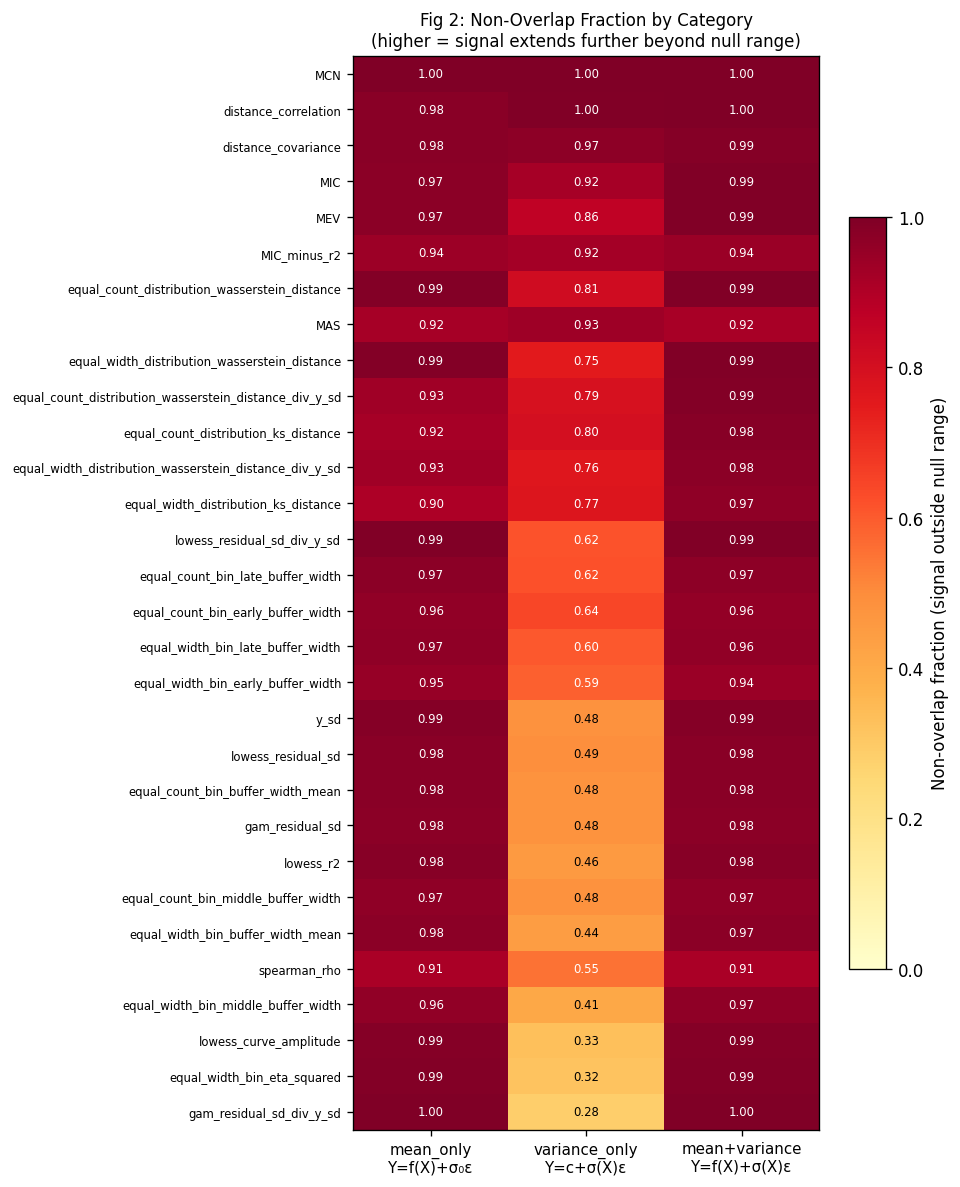

Saved → output/S2.3/fig2_non_overlap_by_category.png


In [28]:
# Pivot: non_overlap per metric × category (averaged over x_distribution)
cat_heat = comp_df.groupby(['metric', 'category'])['non_overlap_frac'].mean().reset_index()
cat_pivot = cat_heat.pivot(index='metric', columns='category', values='non_overlap_frac')
cat_pivot['mean'] = cat_pivot[signal_cats].mean(axis=1)
cat_pivot = cat_pivot.sort_values('mean', ascending=False)

top30 = cat_pivot.head(30)
plot_data = top30[signal_cats].values

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(plot_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=7)
ax.set_xticks(range(len(signal_cats)))
ax.set_xticklabels(['mean_only\nY=f(X)+σ₀ε', 'variance_only\nY=c+σ(X)ε', 'mean+variance\nY=f(X)+σ(X)ε'], fontsize=9)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        color = 'white' if plot_data[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{plot_data[i,j]:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Non-overlap fraction (signal outside null range)', shrink=0.7)
ax.set_title('Fig 2: Non-Overlap Fraction by Category\n(higher = signal extends further beyond null range)', fontsize=10)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2_non_overlap_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig2_non_overlap_by_category.png"}')

## Fig 3: Range Ratio Heatmap (metric × category)

signal_range_95 / null_range_95 per category: how much wider is the signal distribution?
A metric sensitive to mean-shift will show large ratio for mean_only; one sensitive to
variance-change will show large ratio for variance_only.

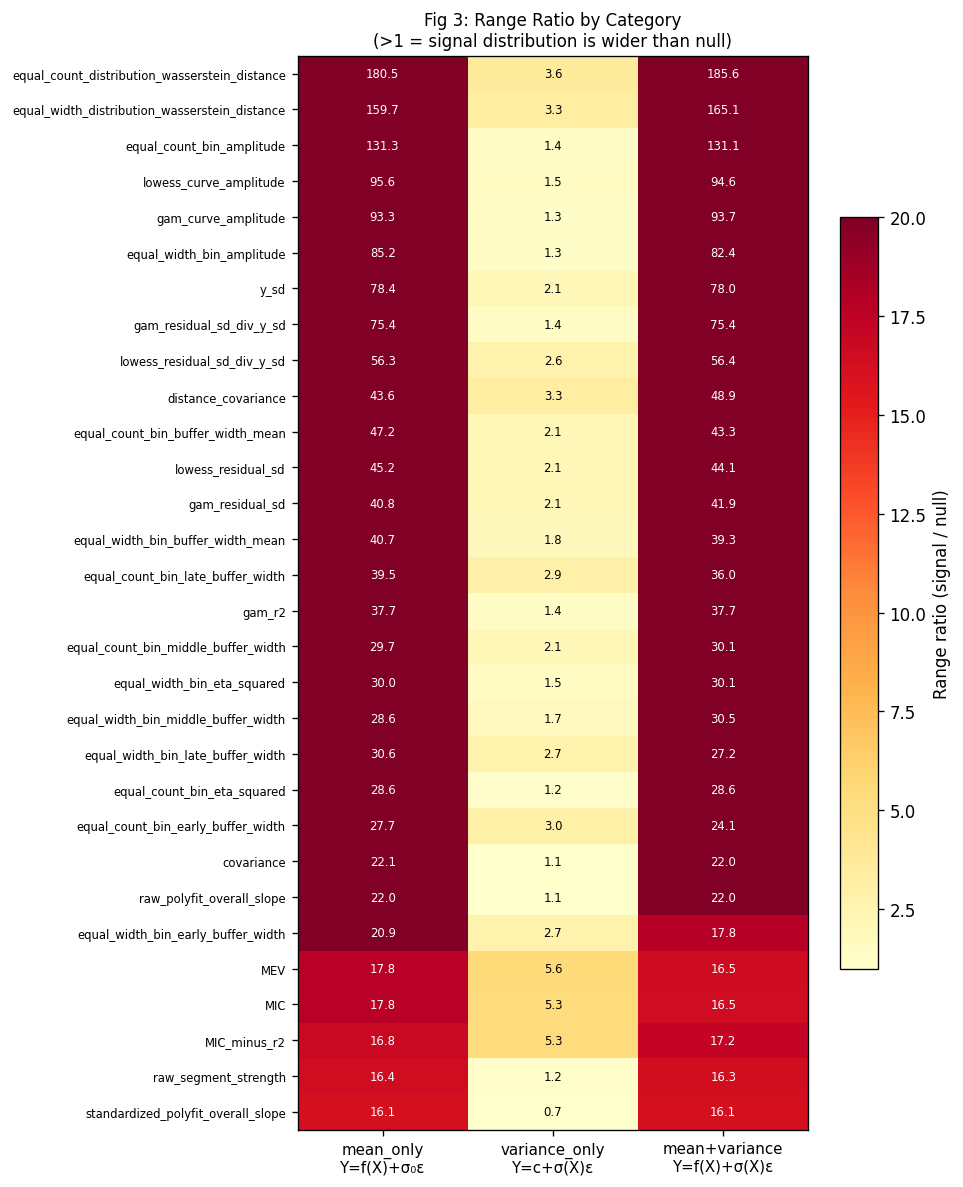

Saved → output/S2.3/fig3_range_ratio_by_category.png


In [29]:
ratio_by_cat = comp_df.groupby(['metric', 'category'])['range_ratio'].mean().reset_index()
ratio_cat_pivot = ratio_by_cat.pivot(index='metric', columns='category', values='range_ratio')
ratio_cat_pivot['mean'] = ratio_cat_pivot[signal_cats].mean(axis=1)
ratio_cat_pivot = ratio_cat_pivot.sort_values('mean', ascending=False)

top30_ratio = ratio_cat_pivot.head(30)
plot_data_r = top30_ratio[signal_cats].values

fig, ax = plt.subplots(figsize=(8, 10))
vmax = min(20, np.nanpercentile(plot_data_r, 95))
im = ax.imshow(plot_data_r, aspect='auto', cmap='YlOrRd', vmin=1, vmax=vmax)
ax.set_yticks(range(len(top30_ratio)))
ax.set_yticklabels(top30_ratio.index, fontsize=7)
ax.set_xticks(range(len(signal_cats)))
ax.set_xticklabels(['mean_only\nY=f(X)+σ₀ε', 'variance_only\nY=c+σ(X)ε', 'mean+variance\nY=f(X)+σ(X)ε'], fontsize=9)

for i in range(plot_data_r.shape[0]):
    for j in range(plot_data_r.shape[1]):
        v = plot_data_r[i, j]
        color = 'white' if v > vmax * 0.5 else 'black'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Range ratio (signal / null)', shrink=0.7)
ax.set_title('Fig 3: Range Ratio by Category\n(>1 = signal distribution is wider than null)', fontsize=10)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig3_range_ratio_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig3_range_ratio_by_category.png"}')

## Fig 4: Best Metrics per Category — Top 15 per Signal Type

Three panels: for each signal category, show the top 15 metrics ranked by non-overlap fraction.
This directly answers: "which metrics best detect mean-shift? variance-change? both?"

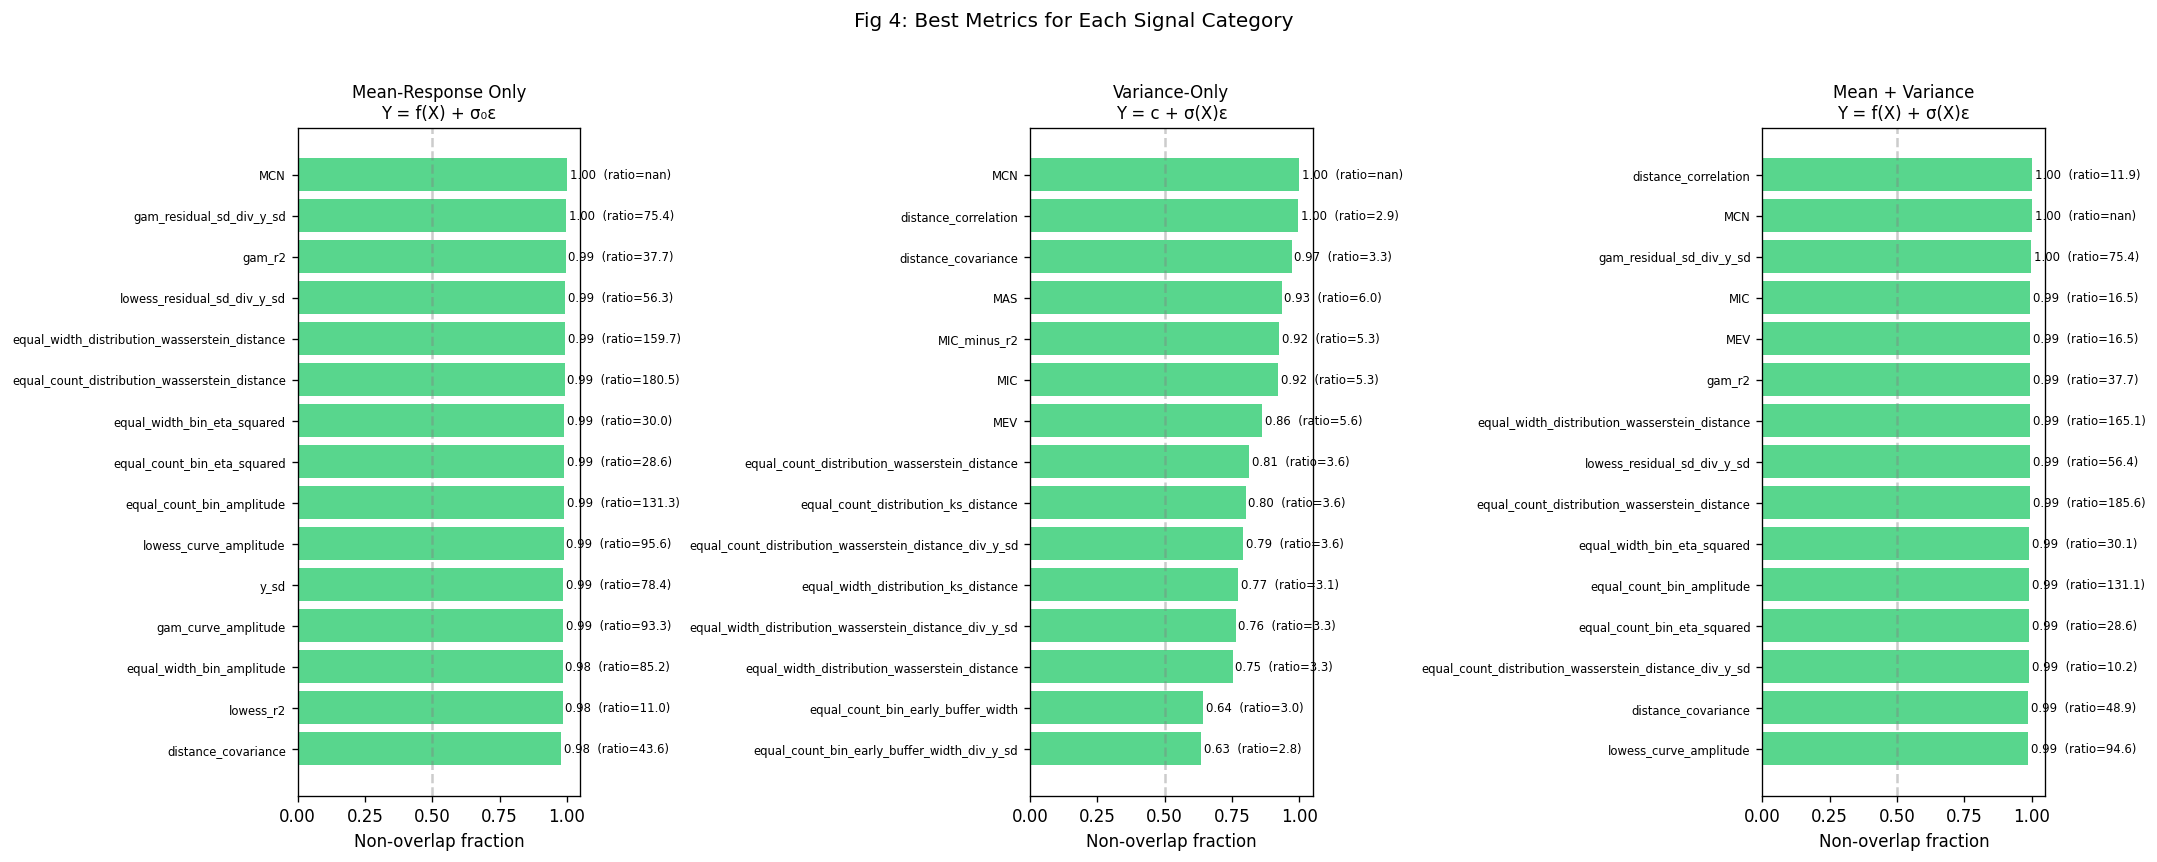

Saved → output/S2.3/fig4_best_per_category.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
cat_titles = {
    'mean_only': 'Mean-Response Only\nY = f(X) + σ₀ε',
    'variance_only': 'Variance-Only\nY = c + σ(X)ε',
    'mean+variance': 'Mean + Variance\nY = f(X) + σ(X)ε',
}

for ax, cat in zip(axes, signal_cats):
    cat_data = agg[agg['category'] == cat].sort_values('mean_non_overlap', ascending=False).head(15)
    vals = cat_data['mean_non_overlap'].values
    colors = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.2 else '#e74c3c' for v in vals]

    ax.barh(range(len(cat_data)), vals, color=colors, alpha=0.8)
    for i, (_, row) in enumerate(cat_data.iterrows()):
        ax.text(row['mean_non_overlap'] + 0.01, i,
                f'{row["mean_non_overlap"]:.2f}  (ratio={row["mean_range_ratio"]:.1f})',
                va='center', fontsize=7)

    ax.set_yticks(range(len(cat_data)))
    ax.set_yticklabels(cat_data['metric'].values, fontsize=7)
    ax.set_xlabel('Non-overlap fraction')
    ax.set_title(cat_titles[cat], fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlim(0, 1.05)

plt.suptitle('Fig 4: Best Metrics for Each Signal Category', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig4_best_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig4_best_per_category.png"}')

## Fig 5: KDE Density — All 75 Metrics

For each metric, overlay the 4 category density distributions.
Gray shaded band = null 95% range. Sorted by non-overlap (same order as Fig 1).

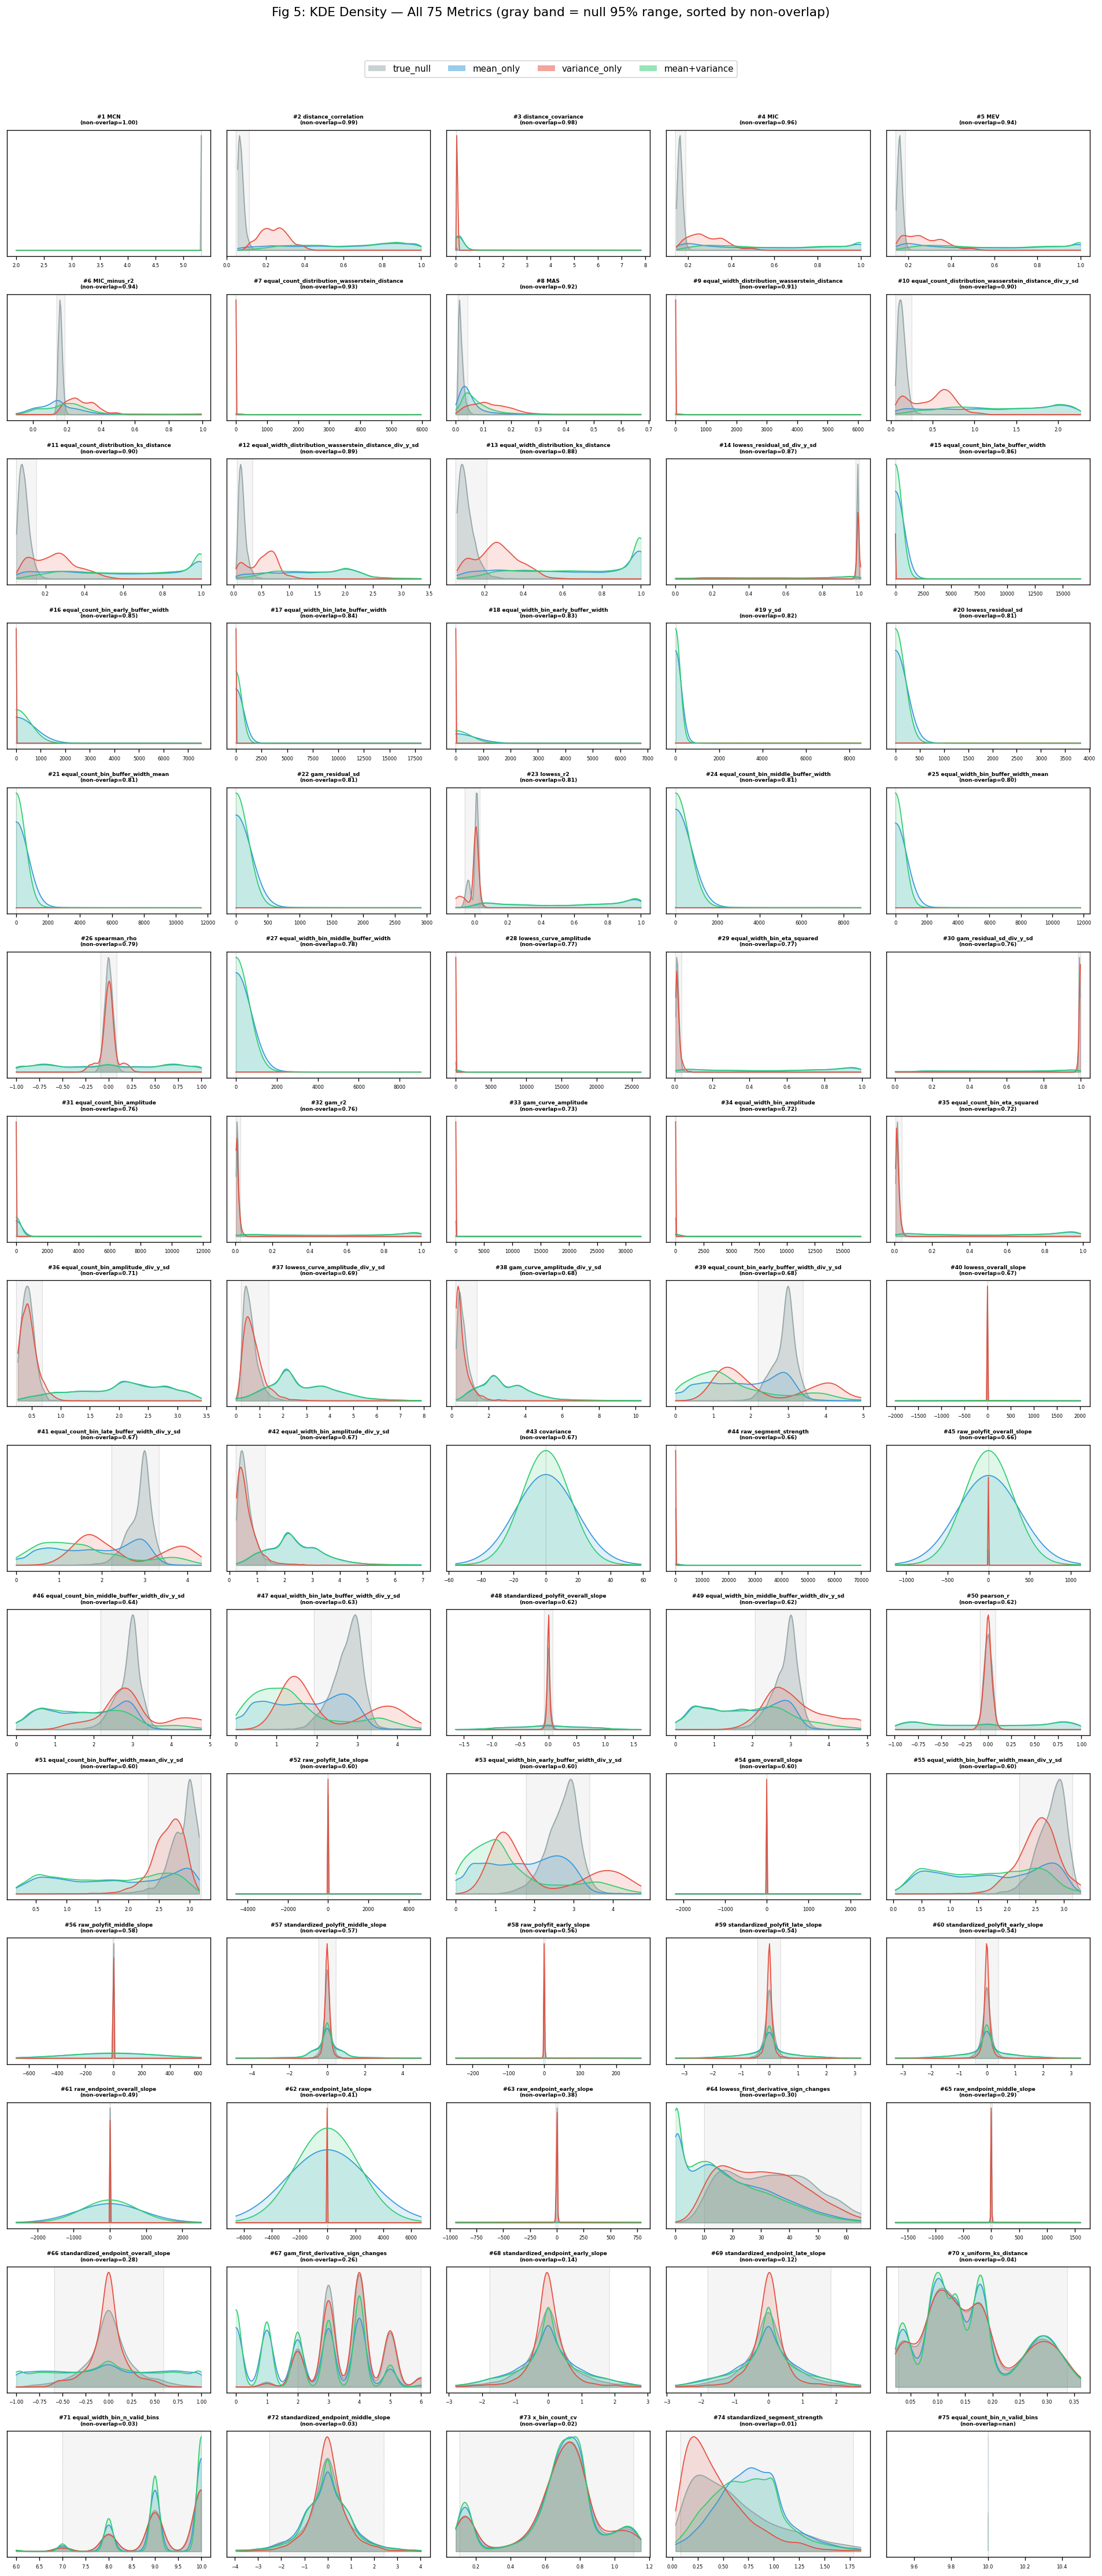

Saved → output/S2.3/fig5_kde_by_category_all.png


In [31]:
from scipy.stats import gaussian_kde

sorted_metrics_kde = overall.index.tolist()
n_metrics_kde = len(sorted_metrics_kde)
n_cols_kde = 5
n_rows_kde = int(np.ceil(n_metrics_kde / n_cols_kde))

fig, axes = plt.subplots(n_rows_kde, n_cols_kde, figsize=(n_cols_kde * 3.2, n_rows_kde * 2.4))
axes_flat = axes.flat

for idx, m in enumerate(sorted_metrics_kde):
    ax = axes_flat[idx]
    all_vals = df[m].dropna().values
    if len(all_vals) < 20:
        ax.set_title(f'#{idx+1} {m}\n(no data)', fontsize=5.5)
        continue
    x_lo = np.percentile(all_vals, 0.5)
    x_hi = np.percentile(all_vals, 99.5)
    x_grid = np.linspace(x_lo, x_hi, 200)

    for cat in categories:
        vals = df.loc[df['category'] == cat, m].dropna().values
        if len(vals) < 20:
            continue
        try:
            kde = gaussian_kde(vals)
            density = kde(x_grid)
            ax.fill_between(x_grid, density,
                            alpha=0.35 if cat == 'true_null' else 0.15,
                            color=cat_colors[cat])
            ax.plot(x_grid, density, color=cat_colors[cat], linewidth=1, label=cat)
        except Exception:
            continue

    null_vals = df.loc[df['category'] == 'true_null', m].dropna().values
    if len(null_vals) >= 5:
        lo, hi = np.percentile(null_vals, [2.5, 97.5])
        ax.axvspan(lo, hi, alpha=0.08, color='gray', zorder=0)
        ax.axvline(lo, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)
        ax.axvline(hi, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)

    score = overall.loc[m, 'mean_non_overlap']
    ax.set_title(f'#{idx+1} {m}\n(non-overlap={score:.2f})', fontsize=5.5, fontweight='bold')
    ax.tick_params(labelsize=5)
    ax.set_yticks([])

for idx in range(n_metrics_kde, n_rows_kde * n_cols_kde):
    axes_flat[idx].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], alpha=0.5, label=c) for c in categories]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle('Fig 5: KDE Density — All 75 Metrics (gray band = null 95% range, sorted by non-overlap)',
             fontsize=13, y=1.03)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_kde_by_category_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig5_kde_by_category_all.png"}')

## Fig 6: x_distribution Stability Check

For each signal category, show non-overlap fraction per x_distribution (top 15 metrics).
This answers: does the range separation hold across all x_distribution types,
or does it break down for certain distributions?

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_45940/451726048.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


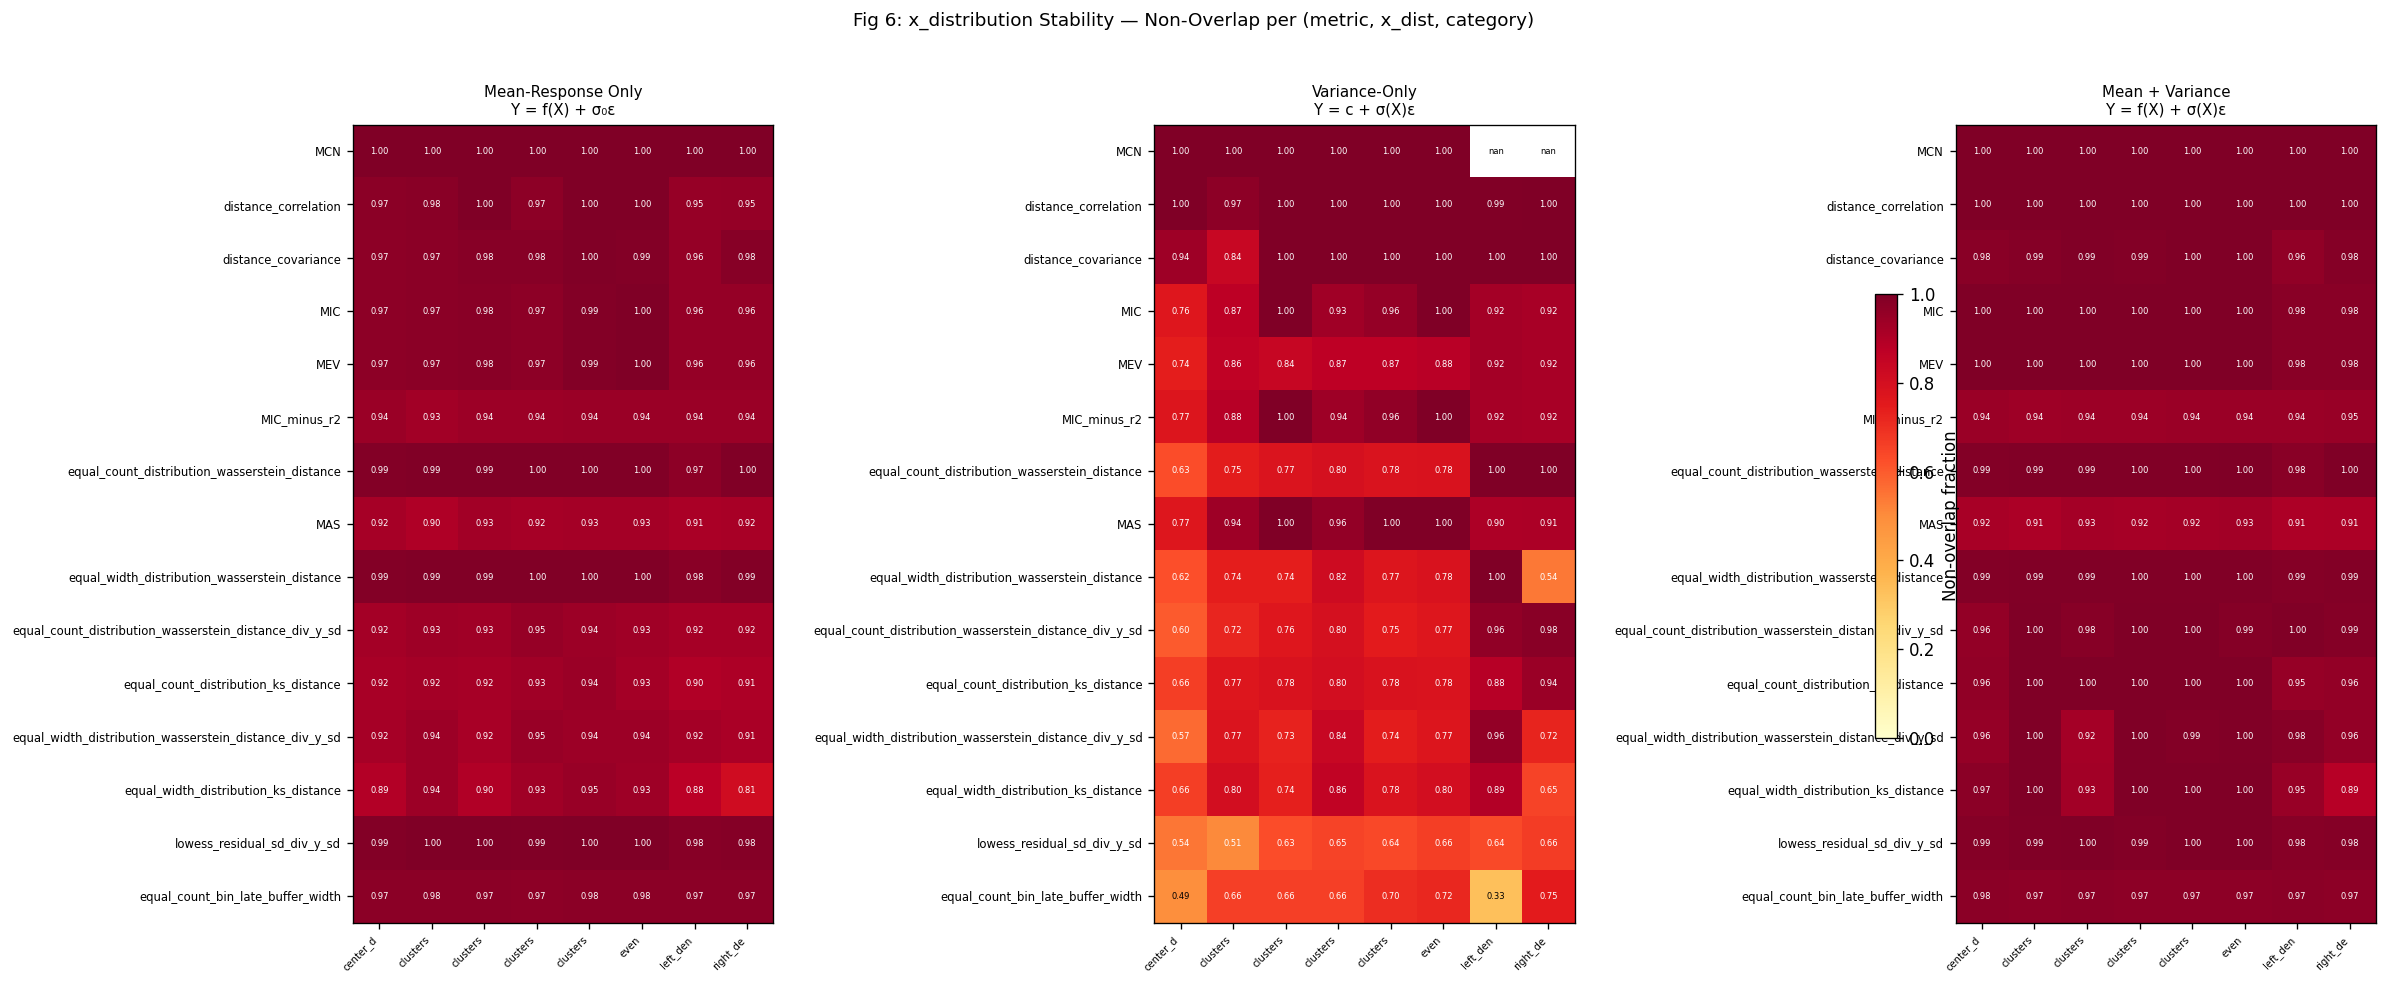

Saved → output/S2.3/fig6_xdist_stability.png


In [32]:
top15_overall = overall.head(15).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, cat in zip(axes, signal_cats):
    cat_data = comp_df[comp_df['category'] == cat]
    xd_pivot = cat_data.pivot_table(index='metric', columns='x_distribution',
                                     values='non_overlap_frac', aggfunc='mean')
    xd_pivot = xd_pivot.loc[[m for m in top15_overall if m in xd_pivot.index]]
    plot_d = xd_pivot[x_dists].values

    im = ax.imshow(plot_d, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_yticks(range(len(xd_pivot)))
    ax.set_yticklabels(xd_pivot.index, fontsize=7)
    ax.set_xticks(range(len(x_dists)))
    ax.set_xticklabels([xd[:8] for xd in x_dists], fontsize=6, rotation=45, ha='right')

    for i in range(plot_d.shape[0]):
        for j in range(plot_d.shape[1]):
            color = 'white' if plot_d[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{plot_d[i,j]:.2f}', ha='center', va='center', fontsize=5, color=color)

    ax.set_title(cat_titles[cat], fontsize=9)

plt.colorbar(im, ax=axes.tolist(), label='Non-overlap fraction', shrink=0.6)
plt.suptitle('Fig 6: x_distribution Stability — Non-Overlap per (metric, x_dist, category)',
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig6_xdist_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig6_xdist_stability.png"}')

## Summary

In [33]:
print('=== Null vs Signal Range Analysis Summary ===')
print()
print('Top 10 metrics by non-overlap fraction (signal range outside null range):')
print(overall.head(10).to_string(float_format='{:.3f}'.format))
print()
print('Top 10 by consistency score (high separation + low x_distribution variance):')
print(consistency.head(10)[['metric', 'mean_non_overlap', 'min_non_overlap', 'cv', 'consistency_score']]
      .to_string(index=False, float_format='{:.3f}'.format))
print()
print('Per signal category — best metrics:')
for cat in signal_cats:
    cat_best = agg[agg['category'] == cat].sort_values('mean_non_overlap', ascending=False).head(5)
    print(f'\n  {cat}:')
    for _, row in cat_best.iterrows():
        print(f'    {row["metric"]:45s}  non_overlap={row["mean_non_overlap"]:.3f}  range_ratio={row["mean_range_ratio"]:.1f}')

# Save
overall.to_csv(VIZ_DIR / 'range_comparison_summary.csv', float_format='%.4f')
consistency.to_csv(VIZ_DIR / 'consistency_scores.csv', index=False, float_format='%.4f')
comp_df.to_csv(VIZ_DIR / 'range_comparisons_detail.csv', index=False, float_format='%.4f')
print(f'\nSaved → {VIZ_DIR}/')

=== Null vs Signal Range Analysis Summary ===

Top 10 metrics by non-overlap fraction (signal range outside null range):
                                                        mean_non_overlap  mean_range_ratio  mean_median_shift
metric                                                                                                       
MCN                                                                1.000               NaN                NaN
distance_correlation                                               0.991             9.426              6.793
distance_covariance                                                0.979            31.963              4.218
MIC                                                                0.963            13.198              6.837
MEV                                                                0.944            13.310              6.755
MIC_minus_r2                                                       0.935            13.110              1.201

NameError: name 'consistency' is not defined